# Lab : POS Tagging

## Objectives:

Use a HMM model (in a *supervised* manner) and a CRF model for a task of POS-Tagging
1. Look at the data: understand the structure, the labels, collect some statistics.
2. Implement a HMM model for **supervised learning**:
    - From scratch: we will need to implement a ```fit``` method. What does MLE gives for our parameters ?
    - We will need to use the Viterbi algorithm for our ```predict``` method
3. Perform classification:
    - Compute accuracy
    - Look at the confusion matrix between tags
4. Use an existing CRF implementation, with handmade features
    - Perform classification and look at the confusion matrix
5. Use an existing HMM implementation, made for **unsupervised learning**
    - Apply it: does it work ?
    - Look at the transition probabilities that are learnt

## Necessary dependencies

We will need the following packages:
- The Natural Language Toolkit : http://www.nltk.org/install.html for our data
- The Machine Learning API Scikit-learn : http://scikit-learn.org/stable/install.html for our methods - our models will be based on the same structure as ```sklearn```, using the ```hmmlearn``` and ```sklearn_crfsuite``` library

In [ ]:
import nltk
import math
import numpy as np
# For visualization
import matplotlib.pyplot as plt
import seaborn as sns
# For counting
from collections import defaultdict, Counter

In [ ]:
!pip install hmmlearn
!pip install sklearn_crfsuite

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 70.5 MB/s eta 0:00:00


In [ ]:
# Models we will use
from hmmlearn import hmm
import sklearn_crfsuite

In [ ]:
# For data
from sklearn.model_selection import train_test_split

The Penn Treebank is a widely used annotated corpus of English, created at the University of Pennsylvania. It contains data from sources such as newspapers, with each sentence annotated for part-of-speech (POS) tags and syntactic structure - it is standard for tasks such as POS tagging and syntactic parsing.
The ```NLTK``` package contains a subset of 10% of this dataset, in ```treebank```:

In [ ]:
nltk.download('treebank')
corpus = nltk.corpus.treebank.tagged_sents()
print(corpus[0])

[nltk_data] Downloading package treebank to /root/nltk_data...
[nltk_data]   Unzipping corpora/treebank.zip.


[('Pierre', 'NNP'), ('Vinken', 'NNP'), (',', ','), ('61', 'CD'), ('years', 'NNS'), ('old', 'JJ'), (',', ','), ('will', 'MD'), ('join', 'VB'), ('the', 'DT'), ('board', 'NN'), ('as', 'IN'), ('a', 'DT'), ('nonexecutive', 'JJ'), ('director', 'NN'), ('Nov.', 'NNP'), ('29', 'CD'), ('.', '.')]


In [ ]:
# Split train/test
train_sents, test_sents = train_test_split(corpus, shuffle = False)

### I - Exploring data

Explore the *training data*:
- Count the number of tags and visualize their frequency,
- Look at the rank / frequency curve of words, in the log-space, to visualize *Zipf's distribution*
- Display an histogram of sentence lengths to have an idea of how the sequences are distributed
<div class='alert alert-block alert-info'>
            Code:</div>

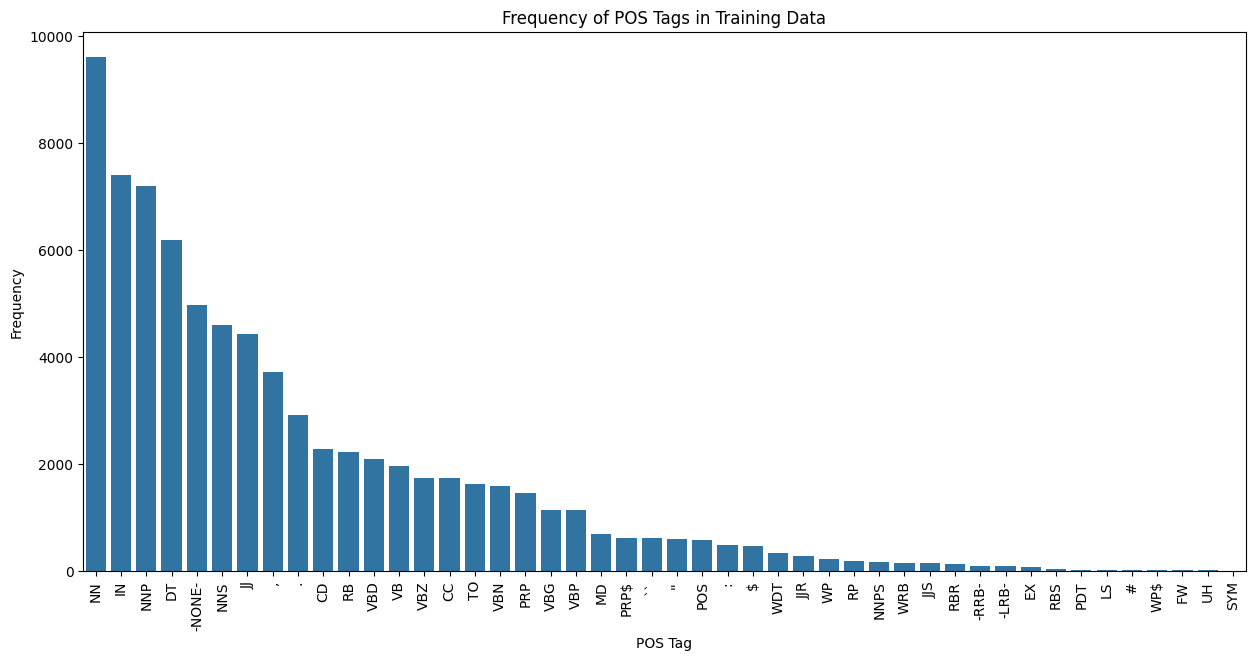

Total unique tags: 46
Most common 10 tags: [('NN', 9600), ('IN', 7396), ('NNP', 7185), ('DT', 6174), ('-NONE-', 4972), ('NNS', 4594), ('JJ', 4428), (',', 3715), ('.', 2917), ('CD', 2275)]


In [ ]:
# count the number of tags and visualize their frequency
tag_counts = Counter()
for sent in train_sents:
    for _, tag in sent:
        tag_counts[tag] += 1

sorted_tags = tag_counts.most_common()
tags = [tag for tag, _ in sorted_tags]
counts = [count for _, count in sorted_tags]

plt.figure(figsize=(15, 7))
sns.barplot(x=tags, y=counts)
plt.title('Frequency of POS Tags in Training Data')
plt.xlabel('POS Tag')
plt.ylabel('Frequency')
plt.xticks(rotation=90)
plt.show()

print("Total unique tags:", len(tag_counts))
print("Most common 10 tags:", tag_counts.most_common(10))

/tmp/ipykernel_16892/349615787.py:8: RuntimeWarning: divide by zero encountered in log
  plt.plot(np.log(rank), np.log(counts))


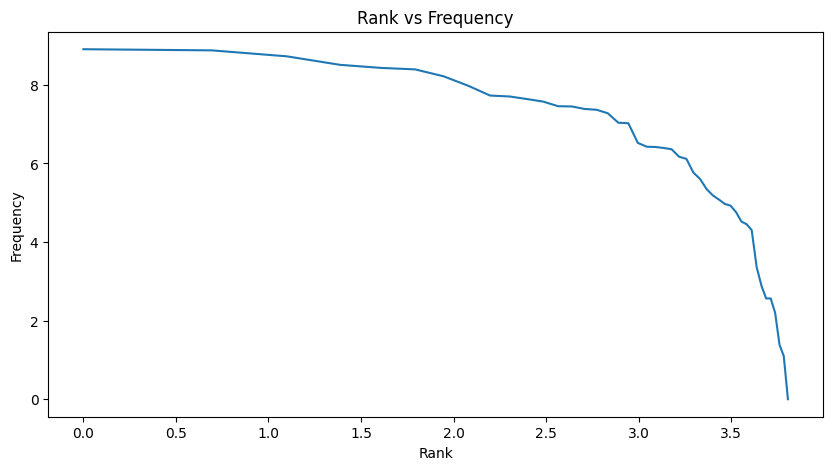

In [ ]:
# rank/frequency of words

rank = [i for i in range(len(sorted_tags))]



plt.figure(figsize=(10,5))
plt.plot(np.log(rank), np.log(counts))
plt.title("Rank vs Frequency")
plt.xlabel("Rank")
plt.ylabel("Frequency")
plt.show()

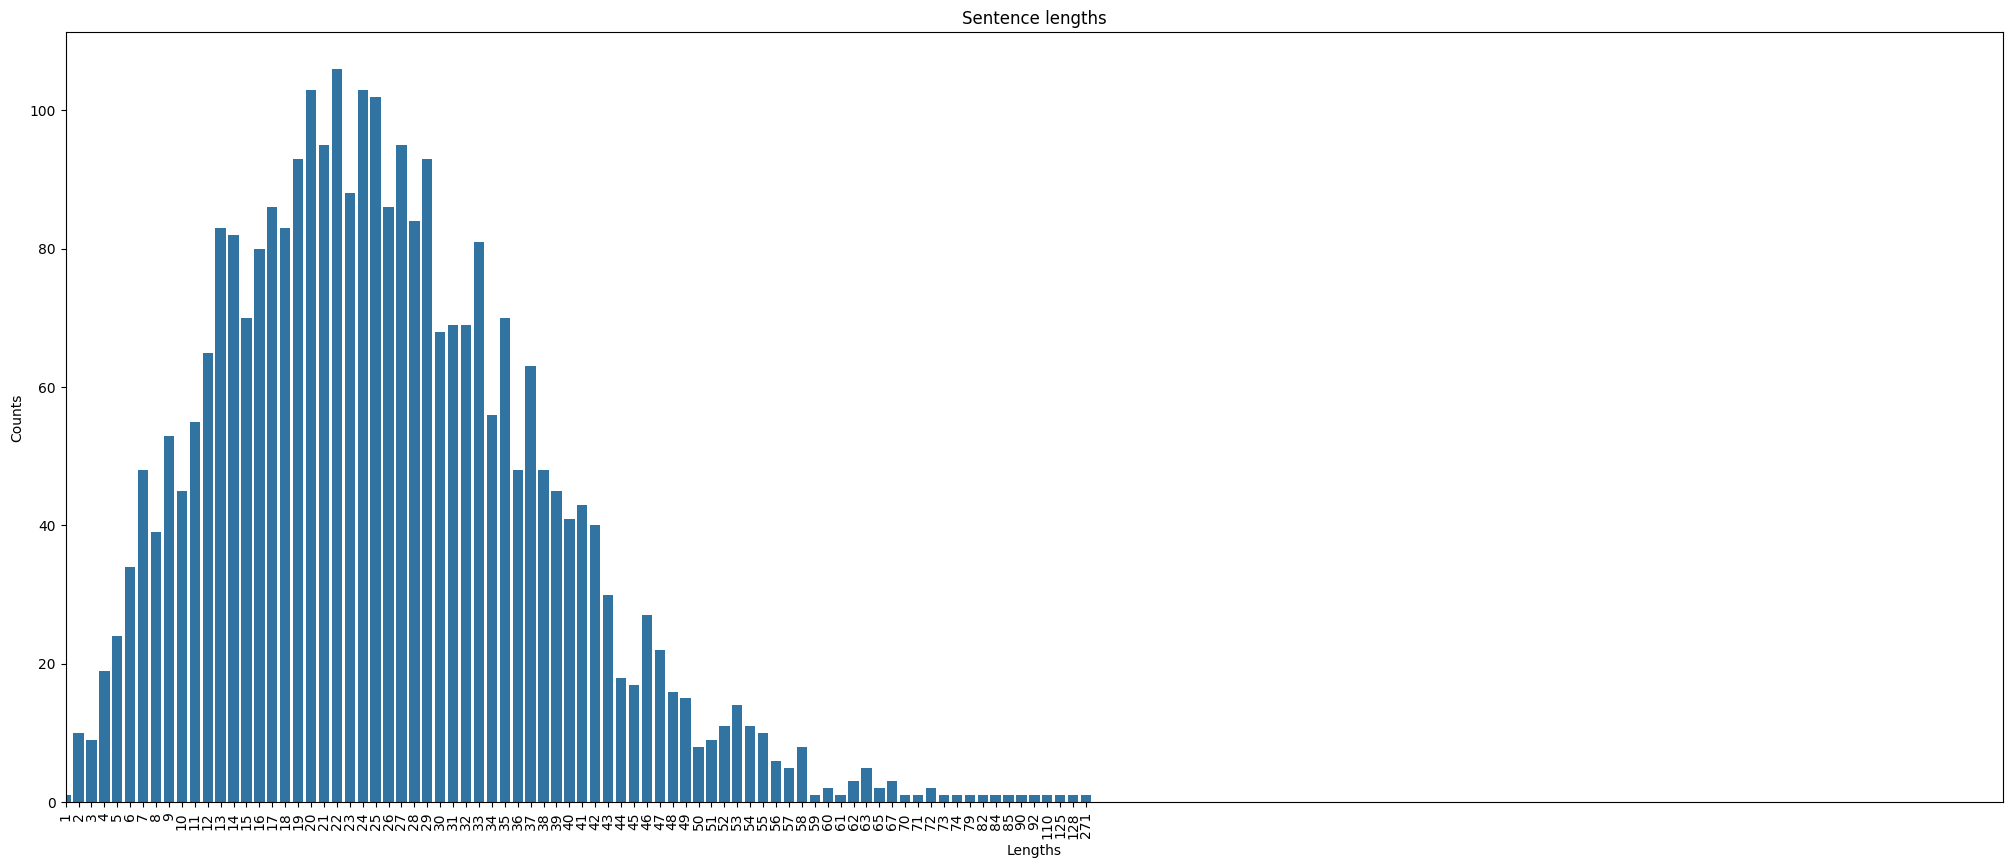

In [ ]:
lengths_count = Counter()

for sent in train_sents:
  lengths_count[len(sent)] += 1

sorted_sents = lengths_count.most_common()
lengths = [length for length,_ in sorted_sents]
counts = [count for _,count in sorted_sents]

plt.figure(figsize=(25,10))
sns.barplot(x=lengths, y=counts)
plt.title("Sentence lengths")
plt.xlabel("Lengths")
plt.ylabel('Counts')
plt.xlim(0,150)
plt.xticks(rotation=90)
plt.show()

## II - Implementing a supervised HMM

We will now implement a ```HMMTagger``` class. It contains:
- A ```fit``` method, which takes as input sentences and their tags and learn HMM parameters: transition probabilities $A$, emission probabilities $B$, initial state probabilities $\pi$
    - What should be the values of these parameters, depending of the frequencies of *tag-tag* transitions and *tag-word* emission observed in data ?
        - We can compute *empirical probabilities*, which would be what we would get if actually computing Maximum Likelihood Estimation
        - This is exactly like learning the parameters of the *Naive Bayes* in the first class
    - We will need to use *smoothing* with $\alpha$ to avoid having a probabilities at $0$.
- A ```predict``` method which takes as input a sequence of words and outputs the most probable sequence of tags given the parameters.
    - It should implement the Viterbi algorithm, including the recursion followed by backtracking.
    - The practical difficulty is to deal with possibly *unknown* words: in this case, we arbitrarily use the emission probability $\frac{1}{|V|}$   
<div class='alert alert-block alert-info'>
            Code:</div>

In [ ]:
class HMMTagger:
    def __init__(self, alpha=1.0):
        self.vocab = set()
        self.tags = set()
        # For Laplace smoothing
        self.alpha = alpha

    # Supervised training: we need to estimate the parameters given the training data
    def fit(self, tagged_sentences):
        # We don't know yet how many tags/words we will encounter
        # We use defaultdict(Counter) to be able to add them along the way
        transition_counts = defaultdict(Counter)
        emission_counts = defaultdict(Counter)
        # We'll need this for initial probabilities
        tag_counts = Counter()

        # Getting counts on all data
        for sent in tagged_sentences:
            prev_tag = "<START>"
            for word, tag in sent:
                self.vocab.add(word)
                self.tags.add(tag)
                # Count transitions of 'prev_tag' to 'tag'
                transition_counts[prev_tag][tag] += 1
                # Count emissions of 'word' for 'tag'
                emission_counts[tag][word] += 1
                # Count tags
                tag_counts[tag] += 1

                prev_tag = tag
            # End transition
            transition_counts[prev_tag]["<END>"] += 1

        # Necessary to get parameters: vocabulary of tags and words
        self.tag_to_idx = {t:i for i,t in enumerate(self.tags)}
        self.idx_to_tag = {i:t for i,t in enumerate(self.tags)}
        self.word_to_idx = {w:i for i,w in enumerate(self.vocab)}
        K = len(self.tags)
        V = len(self.vocab)

        # Transition probabilities
        self.A = np.zeros(shape=(K,K))
        for prev_tag in self.tags:
            # sum all transitions from a specific prev_tag to all tags
            total_transitions = sum(transition_counts[prev_tag].values())
            prev_tag_idx = self.tag_to_idx[prev_tag]
            for curr_tag in self.tags:
                curr_tag_idx = self.tag_to_idx[curr_tag]
                # divide number of transitions prev_tag->curr_tag for the computed sum
                self.A[prev_tag_idx][curr_tag_idx] = (transition_counts[prev_tag][curr_tag] + self.alpha)/(total_transitions + self.alpha*K)


        # Initial state probabilities
        self.pi = np.zeros(shape=(K))
        total_start_transitions = sum(transition_counts['<START>'].values())
        for tag in self.tags:
            tag_idx = self.tag_to_idx[tag]
            self.pi[tag_idx] = (transition_counts['<START>'][tag] + self.alpha)/(self.alpha*K + total_start_transitions)

        # Emission probabilities
        self.B = np.zeros(shape=(K, V))
        for tag in self.tags:
            total_emissions = sum(emission_counts[tag].values())
            for word in self.vocab:
                tag_idx = self.tag_to_idx[tag]
                word_idx = self.word_to_idx[word]
                self.B[tag_idx][word_idx] = (emission_counts[tag][word] + self.alpha) / (total_emissions + self.alpha*V)

    # Prediction: with Viterbi
    def predict(self, sentence):
        K = len(self.tags)
        T = len(sentence)
        # Map words to indexes
        obs = []
        for w in sentence:
            if w in self.word_to_idx:
                obs.append(self.word_to_idx[w])
            else:
                obs.append(-1)  # Unknown word

        # Creating the necessary tables
        delta = np.zeros(shape=(T, K))
        psi = np.zeros(shape=(T, K), dtype=int)

        # Initialization
        if obs[0] == -1:
            # In case of unknown word, we use a uniform probability
            delta[0] = np.log(self.pi) + np.log(1.0 / len(self.vocab))
        else:
            delta[0] = np.log(self.pi) + np.log(self.B[:,obs[0]])

        # Recursion
        for t in range(1, T):
            scores = delta[t-1][:,None] + np.log(self.A)
            psi[t] = np.argmax(scores, axis=0)

            if obs[t] == -1: # Unknown word
                emission = np.full(K, np.log(1.0 / len(self.vocab)))
            else:
                emission = np.log(self.B[:,obs[t]])
            delta[t] = np.max(scores, axis=0) + emission

        # Backtrack
        tags_idx = []
        last = np.argmax(delta[-1,:]) # Best last state
        tags_idx.append(last)
        for t in reversed(range(1, T)):
            last = psi[t][last]
            tags_idx.append(last)
        tags_idx.reverse()

        return [self.idx_to_tag[i] for i in tags_idx]

In [ ]:
# Train
tagger = HMMTagger()
tagger.fit(train_sents)

In [ ]:
# Test on one sentence
words = [w for w, t in test_sents[0]]
true_tags = [t for w, t in test_sents[0]]

pred_tags = tagger.predict(words)
print(list(zip(words, pred_tags)))

[('We', 'PRP'), ('can', 'MD'), ('understand', 'VB'), ('and', 'CC'), ('share', 'VB'), ('the', 'DT'), ('compassion', 'NN'), ('that', 'IN'), ('*T*-2', '-NONE-'), ('makes', 'TO'), ('judges', 'VB'), ('sometimes', 'RB'), ('wish', 'VBN'), ('*-3', '-NONE-'), ('to', 'TO'), ('offer', 'VB'), ('a', 'DT'), ('kind', 'NN'), ('of', 'IN'), ('Solomonic', 'DT'), ('aid', 'NN'), ('to', 'TO'), ('those', 'DT'), ('who', 'WP'), ('*T*-4', '-NONE-'), ("'ve", 'VBP'), ('been', 'VBN'), ('hurt', 'VBN'), ('*-1', '-NONE-'), ('.', '.')]


## III - Evaluation

Complete the following functions, to compute accuracy and visualize the confusion matrix.

<div class='alert alert-block alert-info'>
            Code:</div>

In [ ]:
def pos_accuracy(y_true, y_pred):
    correct = 0
    total = 0
    for true,pred in zip(y_true, y_pred):
      if pred == true:
        correct += 1
      total += 1

    return correct / total

In [ ]:
def evaluate(model):
  test_words = []
  y_pred = []
  y_true = []
  for i,sent in enumerate(test_sents):
    words = [w for w, t in test_sents[i]]
    true_tags = [t for w, t in test_sents[i]]
    pred_tags = model.predict(words)
    test_words.extend(words)
    y_true.extend(true_tags)
    y_pred.extend(pred_tags)
  acc = pos_accuracy(y_true=y_true,y_pred=y_pred)
  print(f"Accuracy: {acc}")
  return acc, y_true, y_pred, test_words

In [ ]:
_,y_true, y_pred, test_words = evaluate(tagger)

Accuracy: 0.8446488831753174


In [ ]:
from sklearn.metrics import confusion_matrix

def plot_confusion(y_true, y_pred, labels):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    plt.figure(figsize=(15,12))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap='Blues')
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("POS Tag Confusion Matrix")
    plt.show()

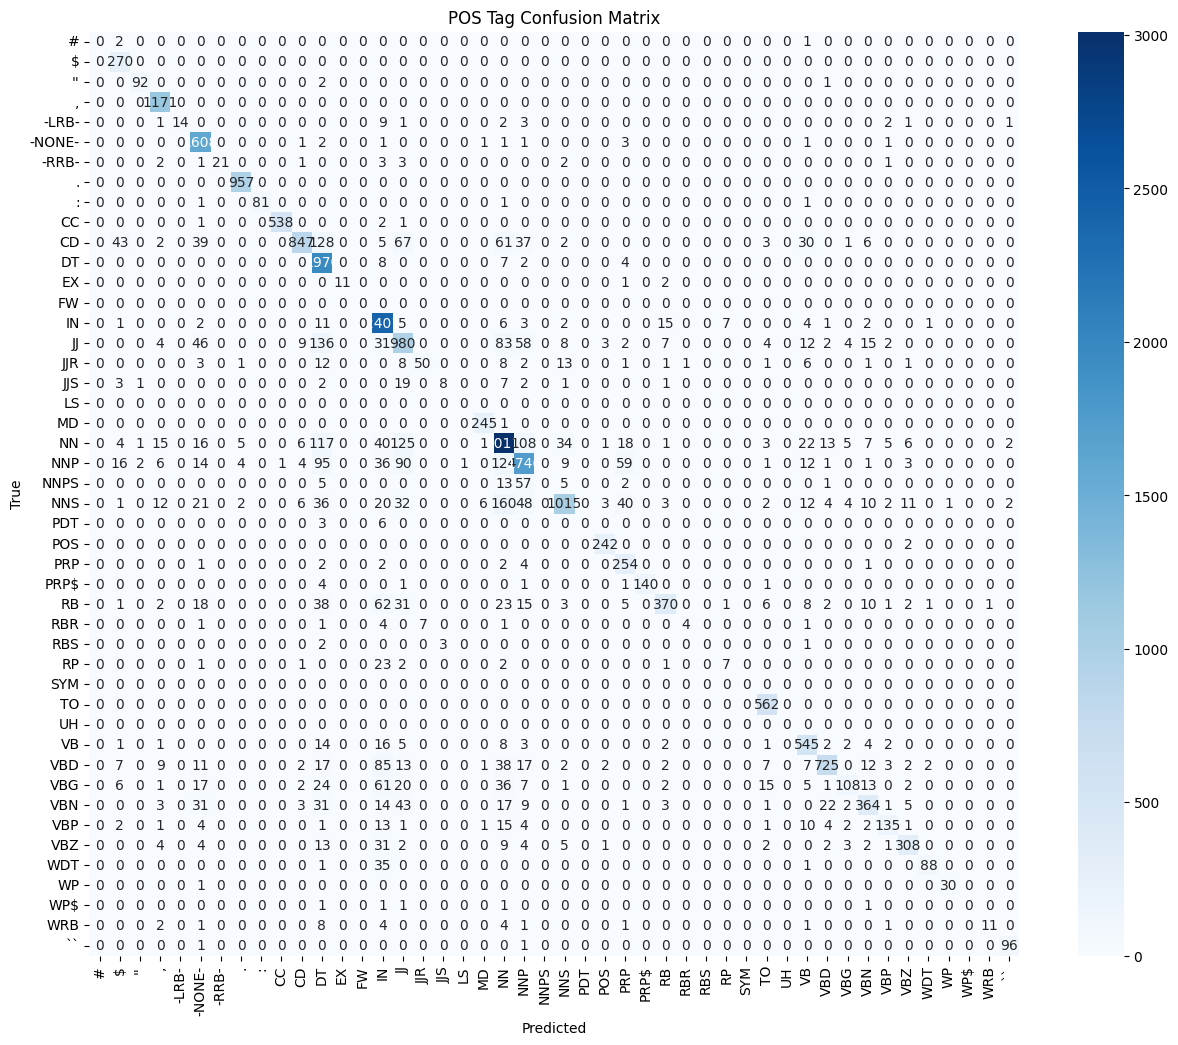

In [ ]:
plot_confusion(y_true, y_pred, sorted(list(tagger.tags)))

Look at the confusion matrix for the test data. Give the most common errors made by the model. Check the tag documentation to try to understand where they might come from.

<div class='alert alert-block alert-warning'>
            Question:</div>

In [ ]:
for w, yt, yp in zip(test_words, y_true, y_pred):
    if (yt == 'NNS' and yp == 'NN') or (yt == 'NN' and yp == 'NNS'):
        print(w, yt, yp)


failures NNS NN
process NN NNS
courts NNS NN
labels NNS NN
daughters NNS NN
users NNS NN
mothers NNS NN
pills NNS NN
defendants NNS NN
warranties NNS NN
damages NNS NN
apples NNS NN
takings NNS NN
defendants NNS NN
justices NNS NN
drugs NNS NN
drugs NNS NN
drugs NNS NN
daughters NNS NN
courts NNS NN
vaccines NNS NN
Everyone NN NNS
justices NNS NN
guilders NNS NN
guilders NNS NN
guilders NNS NN
guilders NNS NN
guilders NNS NN
guilders NNS NN
incisions NNS NN
incentives NNS NN
sidelines NNS NN
Volume NN NNS
rumors NNS NN
yen NNS NN
yen NN NNS
rumors NNS NN
yen NN NNS
yen NN NNS
sidelines NNS NN
highs NNS NN
qualities NNS NN
containers NNS NN
respondents NNS NN
industries NNS NN
reports NNS NN
economists NNS NN
contrary NN NNS
tires NNS NN
lobbyists NNS NN
emissions NNS NN
utilities NNS NN
emissions NNS NN
emissions NNS NN
utilities NNS NN
credits NNS NN
polluters NNS NN
utilities NNS NN
jumps NNS NN
lawmakers NNS NN
utilities NNS NN
headquarters NNS NN
responsibilities NNS NN
backgrounds

#### **ANSWER:**

The most common error is substituting NNS (noun, common plural) for NN (noun, common, singular or mass).


One main reason is that the model has no morphology awareness, that means that it misses the strongest signal that a word is plural (the "s" the end).

Since NNS and NN will have really similar context, the transitions do not help much and the model fails to identify the plural forms.

## IV - Using a CRF

In this part, we will use a ```CRF``` model from the ```sklearn_crfsuite``` package.
The CRF is a supervised model, which uses *local features* that are aggregated through Viterbi when we want to do a prediction.
Learning is made through parameter updates - however, computing those gradients would require implementing the baum-welch algorithm ! So, we will stick to an existing implementation.

We will use the following ```word_features``` function, which will give us a dictionary of features for each position in the sentence.

In [ ]:
def word_features(sentence, i):
    word = sentence[i][0]
    features = {
        'word': word,
        'is_first': i == 0,
        'is_last': i == len(sentence) - 1,
        'is_capitalized': word[0].upper() == word[0],
        'is_all_caps': word.upper() == word,
        'is_all_lower': word.lower() == word,
        'prefix-1': word[0],
        'prefix-2': word[:2],
        'prefix-3': word[:3],
        'suffix-1': word[-1],
        'suffix-2': word[-2:],
        'suffix-3': word[-3:],
        'prev_word': '' if i == 0 else sentence[i-1][0],
        'next_word': '' if i == len(sentence)-1 else sentence[i+1][0],
        'has_hyphen': '-' in word,
        'is_numeric': word.isdigit(),
        'capitals_inside': word[1:].lower() != word[1:]
    }
    return features

We need then to convert data at the right format to train the mode, do prediction, and compute accuracy.
Complete the following:

<div class='alert alert-block alert-info'>
            Code:</div>

In [ ]:
def data_crf(sentences):
    X = []
    y = []
    for sent in sentences:
        X_sent = []
        y_sent = []
        for i, (word, tag) in enumerate(sent):
            X_sent.append(word_features(sent, i))
            y_sent.append(tag)
        X.append(X_sent)
        y.append(y_sent)
    return X, y

In [ ]:
X_train, y_train = data_crf(train_sents)
X_test, y_test = data_crf(test_sents)

In [ ]:
crf = sklearn_crfsuite.CRF(
    algorithm='lbfgs',
    c1=0.1,
    c2=0.1,
    max_iterations=100,
    all_possible_transitions=True
)
crf.fit(X_train, y_train)
y_pred = crf.predict(X_test)

Compare the results with our HMM model, in terms of accuracy and confusion matrix. Try to explain them using your knowledge of the models.

<div class='alert alert-block alert-warning'>
            Question:</div>

In [ ]:
y_true = []
for sent in y_test:
  for tag in sent:
    y_true.append(tag)
y_pred_flat = []
for sent in y_pred:
  for tag in sent:
    y_pred_flat.append(tag)

In [ ]:
print(f"Accuracy : {pos_accuracy(y_true, y_pred_flat)}")

Accuracy : 0.9627591193957898


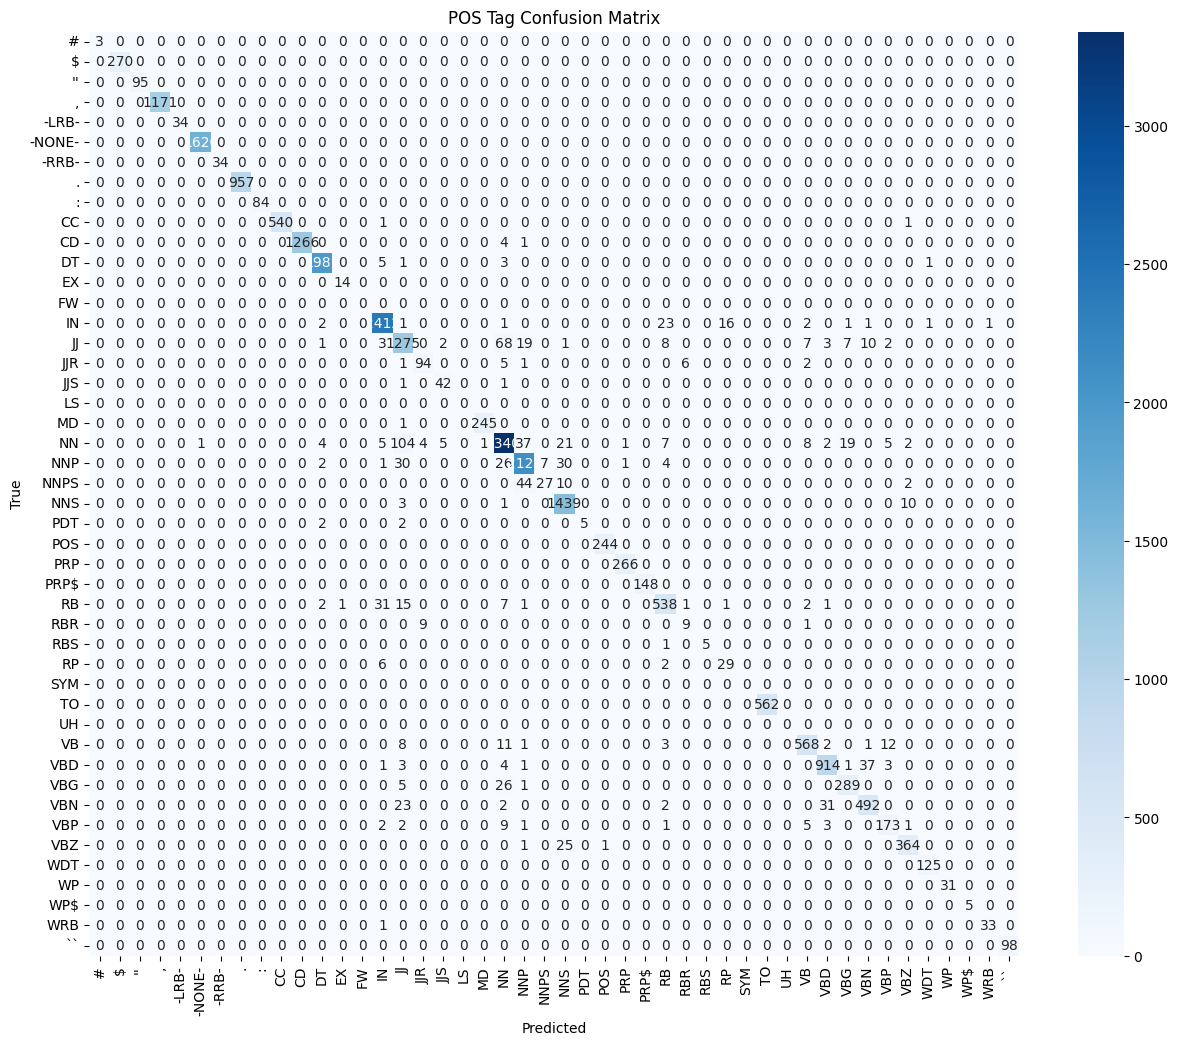

In [ ]:
plot_confusion(y_true, y_pred_flat,sorted(list(tagger.tags)))

#### **ANSWER**

We can see that CRF had a much better performance than supervised HMM.

That probably happens because CRF includes more context by analyzing the features.

The most confused labels by HMM, true label NNS and predidcted NN, dropped significantly (from 160 mistakes to 1). We can assume that happened due to the feature that checks last character. If we know that the word ends with "s" it is way easier to differentiate between NNS and NN.

## V - Using a HMM in an unsupervised manner

In the last part of this lab, we may want to use an existing HMM library: ```hmmlearner`̀ `
Here is the documentation: https://hmmlearn.readthedocs.io/en/latest/index.html

Looking at the proposed model, we can see there is no **supervised learning option in this library**.
Still, we can test to train the model in an *unsupervised manner*. Your task here is:
- To pick the right ```hmmlearner``` model - which one, in the documentation, is better suited to our task ?
- To transform the data into a format adapted to this model - you will need to implement your own vocabulary !
- Compute the accuracy. Were those results expected ?
- Visualize the transition probability matrices of the first HMM trained, and this one. Again, try to look at the high values in the matrux and check if they make sense.

<div class='alert alert-block alert-info'>
            Code:</div>
            
<div class='alert alert-block alert-warning'>
            Question:</div>

In [ ]:
from hmmlearn import hmm

In [ ]:
# Build vocabulary by assigning an id to each word
def build_vocab(sentences):
    vocab = {"<UNK>": 0}
    for sentence in sentences:
        for word, tag in sentence:
            if word not in vocab:
                vocab[word] = len(vocab)
    return vocab

# Encoding sentences according to the previous id assigned in the vocabulary
def encode_sentences(sentences, vocab, unk_token="<UNK>"):
    encoded_data = []
    unk_id = vocab[unk_token]

    for sentence in sentences:
        encoded_sentence = []
        for word, tag in sentence:
            encoded_sentence.append(vocab.get(word, unk_id))
        encoded_data.append(encoded_sentence)

    X = np.concatenate(encoded_data).reshape(-1, 1)
    lengths = [len(s) for s in encoded_data]
    return X, lengths

In [ ]:
# Train
vocab = build_vocab(train_sents)

X_train, lengths_train = encode_sentences(train_sents, vocab)
X_test, lengths_test = encode_sentences(test_sents, vocab)

model = hmm.CategoricalHMM(n_components=len(tag_counts), random_state=42)
model.fit(X_train, lengths_train)

CategoricalHMM(n_components=46, n_features=np.int64(10635),
               random_state=RandomState(MT19937) at 0x7C41EDBCE040)

In [ ]:
# accuracy

train_states = model.predict(X_train, lengths_train)
test_states = model.predict(X_test, lengths_test)

state_tag_map = {}

state_tag_counts = defaultdict(list)

# We will reuse y_train from the used while training CRF, but we need to flatten it first
y_train = [tag for sent in train_sents for _, tag in sent]
y_test = [tag for sent in test_sents for _, tag in sent]

for state, tag in zip(train_states, y_train):
    state_tag_counts[state].append(tag)

for state in state_tag_counts:
    most_common_tag = Counter(state_tag_counts[state]).most_common(1)[0][0]
    state_tag_map[state] = most_common_tag

mapped_test_tags = [state_tag_map[state] for state in test_states]

accuracy = sum(p == t for p, t in zip(mapped_test_tags, y_test)) / len(y_test)
print("Accuracy:", accuracy)

Accuracy: 0.12192672344528363


In [ ]:
def plot_hmm_matrix(matrix, tags):
    plt.figure(figsize=(10,8))
    sns.heatmap(matrix, xticklabels=tags, yticklabels=tags, cmap="viridis", annot=False)
    plt.xlabel("To tag")
    plt.ylabel("From tag")
    plt.title("Transition Matrix")
    plt.show()

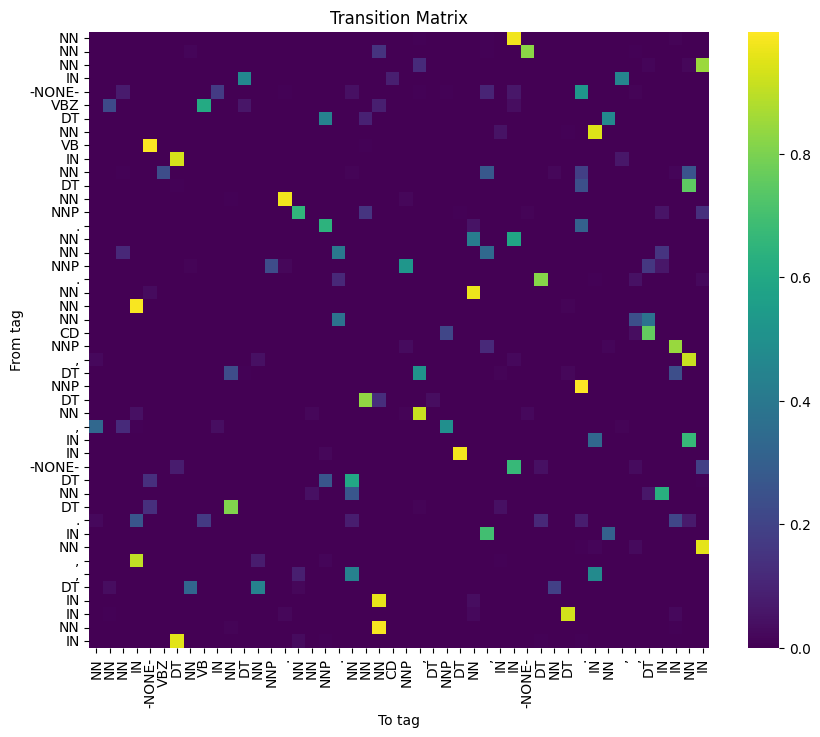

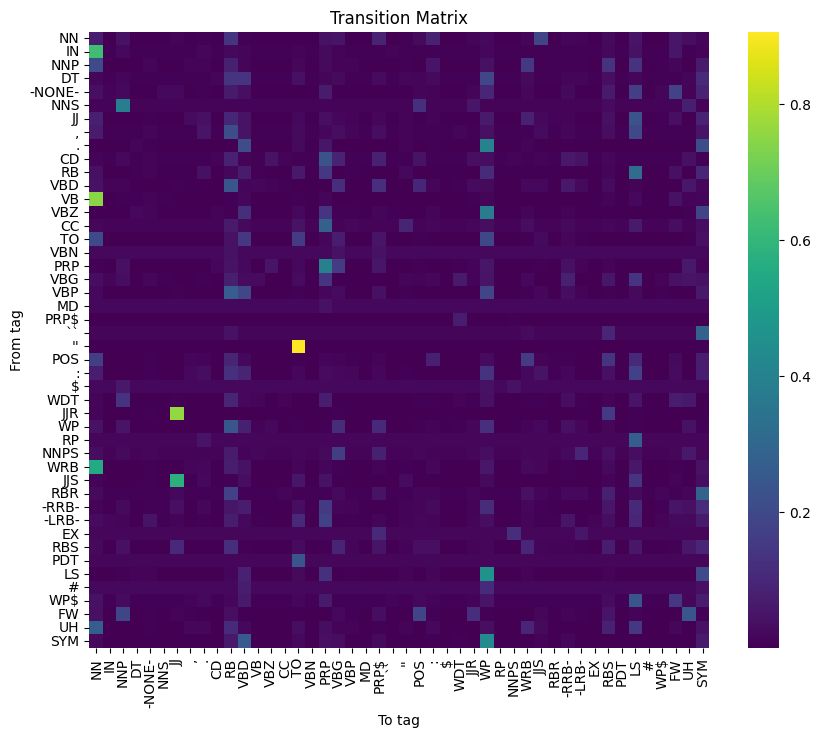

In [ ]:
# For a model in hmmlearner, you find the transition matrix as model.transmat_

state_labels = [state_tag_map.get(i, f"S{i}") for i in range(model.n_components)]

# hmmlearn model
plot_hmm_matrix(model.transmat_, state_labels)

# your previous model
plot_hmm_matrix(tagger.A, tags)


#### **Answer**

The best suited model is Categorical HMM, because the emissions were counted directly from observations.

The accuracy is low (12.19%), but this was expected as the model is unsupervised. Thus, the found hidden tags are not aligned to the true hidden tags.

The supervised transition matrix shows clearer and more interpretable patterns than the unsupervised one. Also, the unsupervised matrix is noisier because hidden states do not directly correspond to POS tags.
In the unsupervised case, multiple hidden states may represent the same POS tag, leading to a fragmented and sparse structure.

The high values in the unsupervised matrix make sense, specially the transitions from IN (preposition) to DT (determiner) and from DT to NN (noun), but they are in many cases repeated to the same POS tag.